In [1]:
# import standard python libraries
import matplotlib as mpl
%matplotlib inline
mpl.rcParams['figure.dpi'] = 96
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os, subprocess
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# import libraries for biological data analysis
from coolpuppy import coolpup
from coolpuppy.lib import numutils
from coolpuppy.lib.puputils import divide_pups
from coolpuppy import plotpup
import cooler
import bioframe
import cooltools
from cooltools import expected_cis, expected_trans
from cooltools.lib import plotting

%cd /home/varshini/uc_analyses/
import utils
%cd /home/varshini/LoopCall_Analysis_Scripts

# plot formatting
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True


/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [2]:
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/match_quantiles'
savedir = '/mnt/md0/varshini/Analysis/Blood/figs_v2/pileups/match_quantiles'

In [3]:
# load coolers, expected values, hg38 arms 
phases= ['Phase1_','Phase2_dedup', 'Phase3_dedup']
expdir = os.path.join('/mnt/md0/varshini/Analysis/Blood', 'microc_expected')
phase_clr_names = [f'/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_{p}merged.250.mcool::resolutions/5000' for p in phases]

#[cooler.fileops.list_coolers(c) for c in phase_clr_names]
phase_clrs = [cooler.Cooler(c) for c in phase_clr_names]
exps = [os.path.join(expdir, f"P_s_{phase}_5000bp_hg38arms.tsv") for phase in phases]

hg38_arms = utils.get_hg38_arms()

INFO:coolpuppy:('chr8_p', 'chr8_p'): 75
INFO:coolpuppy:('chr5_p', 'chr5_p'): 49
INFO:coolpuppy:('chr7_p', 'chr7_p'): 114
INFO:coolpuppy:('chr6_p', 'chr6_p'): 174
INFO:coolpuppy:('chr4_p', 'chr4_p'): 64
INFO:coolpuppy:('chr3_p', 'chr3_p'): 152
INFO:coolpuppy:('chr1_p', 'chr1_p'): 290
INFO:coolpuppy:('chr2_p', 'chr2_p'): 179
INFO:coolpuppy:('chr7_q', 'chr7_q'): 160
INFO:coolpuppy:('chr8_q', 'chr8_q'): 166
INFO:coolpuppy:('chr9_p', 'chr9_p'): 59
INFO:coolpuppy:('chr6_q', 'chr6_q'): 167
INFO:coolpuppy:('chr10_p', 'chr10_p'): 78
INFO:coolpuppy:('chr5_q', 'chr5_q'): 237
INFO:coolpuppy:('chr3_q', 'chr3_q'): 233
INFO:coolpuppy:('chr4_q', 'chr4_q'): 183
INFO:coolpuppy:('chr11_p', 'chr11_p'): 97
INFO:coolpuppy:('chr12_p', 'chr12_p'): 81
INFO:coolpuppy:('chr1_q', 'chr1_q'): 249
INFO:coolpuppy:('chr9_q', 'chr9_q'): 173
INFO:coolpuppy:('chr16_p', 'chr16_p'): 67
INFO:coolpuppy:('chr14_q', 'chr14_q'): 177
INFO:coolpuppy:('chr17_p', 'chr17_p'): 45
INFO:coolpuppy:('chr16_q', 'chr16_q'): 99
INFO:coolpup

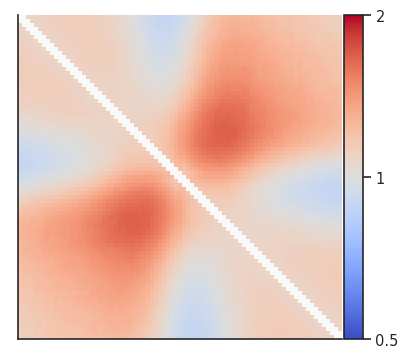

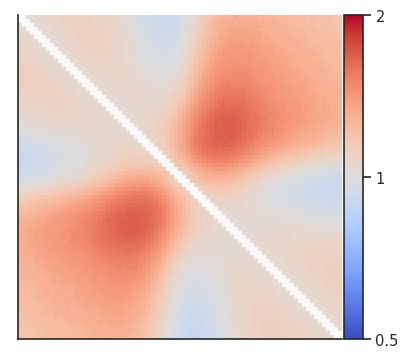

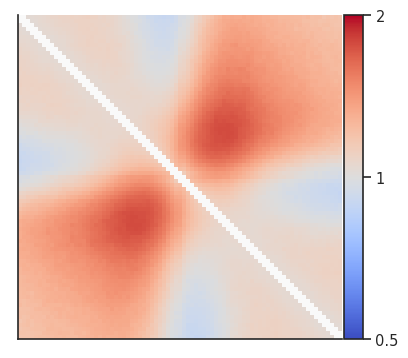

In [4]:
## matchmakers only 
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/'
subdir = 'enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed'
track = pd.read_csv(os.path.join(datapath, subdir), sep='\t')

track_sub = track[(track['quant']==2) | (track['quant']==3)]
track_sub['chrom'] = track_sub['chr']
track_sub['start'] = track_sub['coord']-100
track_sub['end'] = track_sub['coord']+100
    
for p in [0, 1, 2]:
    clr = phase_clrs[p]
    exp0 =  pd.read_csv(exps[p], sep='\t')
    
    pup = coolpup.pileup(clr, track_sub, features_format='bed', local=True, view_df=hg38_arms,
                                        flank=200_000, expected_df = exp0, min_diag=0, nproc=8)
    fg = plotpup.plot(pup,
                             score=False, cmap='coolwarm', scale='log', sym=True,
                             height=5, vmax=2)

    fg
    #fg.savefig(os.path.join(savedir, f"matchmaker_enh_joined_p{p+1}.svg"))
    

INFO:coolpuppy:('chr8_p', 'chr8_p'): 25
INFO:coolpuppy:('chr5_p', 'chr5_p'): 11
INFO:coolpuppy:('chr4_p', 'chr4_p'): 14
INFO:coolpuppy:('chr6_p', 'chr6_p'): 54
INFO:coolpuppy:('chr7_p', 'chr7_p'): 28
INFO:coolpuppy:('chr3_p', 'chr3_p'): 47
INFO:coolpuppy:('chr2_p', 'chr2_p'): 44
INFO:coolpuppy:('chr7_q', 'chr7_q'): 27
INFO:coolpuppy:('chr8_q', 'chr8_q'): 42
INFO:coolpuppy:('chr9_p', 'chr9_p'): 13
INFO:coolpuppy:('chr10_p', 'chr10_p'): 22
INFO:coolpuppy:('chr9_q', 'chr9_q'): 45
INFO:coolpuppy:('chr3_q', 'chr3_q'): 48
INFO:coolpuppy:('chr6_q', 'chr6_q'): 39
INFO:coolpuppy:('chr1_p', 'chr1_p'): 72
INFO:coolpuppy:('chr5_q', 'chr5_q'): 66
INFO:coolpuppy:('chr4_q', 'chr4_q'): 35
INFO:coolpuppy:('chr10_q', 'chr10_q'): 41
INFO:coolpuppy:('chr11_p', 'chr11_p'): 26
INFO:coolpuppy:('chr12_p', 'chr12_p'): 16
INFO:coolpuppy:('chr16_p', 'chr16_p'): 15
INFO:coolpuppy:('chr2_q', 'chr2_q'): 49
INFO:coolpuppy:('chr15_q', 'chr15_q'): 41
INFO:coolpuppy:('chr13_q', 'chr13_q'): 29
INFO:coolpuppy:('chr17_p',

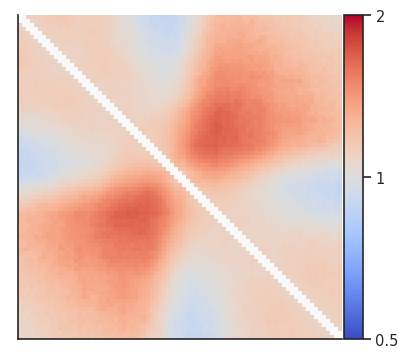

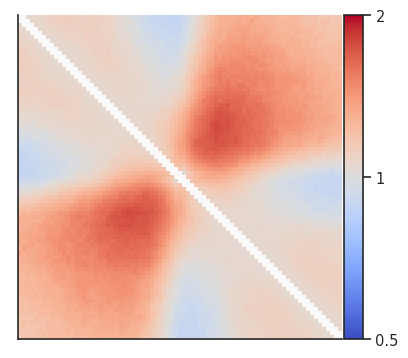

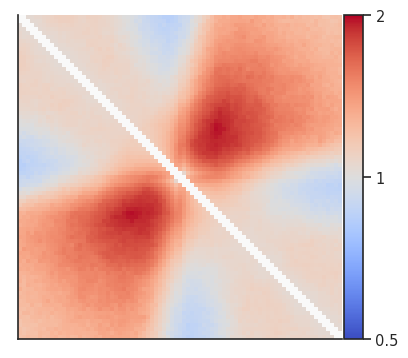

In [6]:
## matchmakers only 
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/'
subdir = 'erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed'
track = pd.read_csv(os.path.join(datapath, subdir), sep='\t')

track_sub = track[(track['quant']==2) | (track['quant']==3)]
track_sub['chrom'] = track_sub['chr']
track_sub['start'] = track_sub['coord']-100
track_sub['end'] = track_sub['coord']+100
    
for p in [0, 1, 2]:
    clr = phase_clrs[p]
    exp0 =  pd.read_csv(exps[p], sep='\t')
    
    pup = coolpup.pileup(clr, track_sub, features_format='bed', local=True, view_df=hg38_arms,
                                        flank=200_000, expected_df = exp0, min_diag=0, nproc=8)
    fg = plotpup.plot(pup,
                             score=False, cmap='coolwarm', scale='log', sym=True,
                             height=5, vmax=2)

    fg.savefig(os.path.join(savedir, f"matchmaker_joined_p{p+1}.svg"))
    

INFO:coolpuppy:('chr5_p', 'chr5_p'): 14
INFO:coolpuppy:('chr8_p', 'chr8_p'): 26
INFO:coolpuppy:('chr4_p', 'chr4_p'): 20
INFO:coolpuppy:('chr6_p', 'chr6_p'): 68
INFO:coolpuppy:('chr7_p', 'chr7_p'): 41
INFO:coolpuppy:('chr3_p', 'chr3_p'): 66
INFO:coolpuppy:('chr2_p', 'chr2_p'): 63
INFO:coolpuppy:('chr1_p', 'chr1_p'): 107
INFO:coolpuppy:('chr8_q', 'chr8_q'): 57
INFO:coolpuppy:('chr7_q', 'chr7_q'): 63
INFO:coolpuppy:('chr6_q', 'chr6_q'): 46
INFO:coolpuppy:('chr10_p', 'chr10_p'): 18
INFO:coolpuppy:('chr9_p', 'chr9_p'): 27
INFO:coolpuppy:('chr11_p', 'chr11_p'): 46
INFO:coolpuppy:('chr3_q', 'chr3_q'): 64
INFO:coolpuppy:('chr5_q', 'chr5_q'): 79
INFO:coolpuppy:('chr4_q', 'chr4_q'): 58
INFO:coolpuppy:('chr12_p', 'chr12_p'): 24
INFO:coolpuppy:('chr1_q', 'chr1_q'): 102
INFO:coolpuppy:('chr9_q', 'chr9_q'): 74
INFO:coolpuppy:('chr10_q', 'chr10_q'): 63
INFO:coolpuppy:('chr2_q', 'chr2_q'): 72
INFO:coolpuppy:('chr16_p', 'chr16_p'): 25
INFO:coolpuppy:('chr11_q', 'chr11_q'): 54
INFO:coolpuppy:('chr14_q',

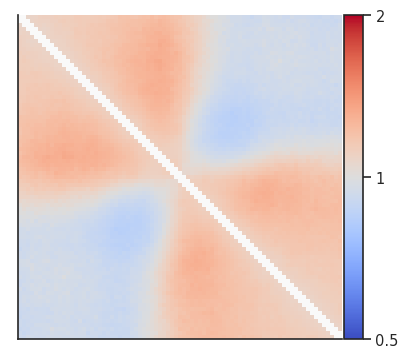

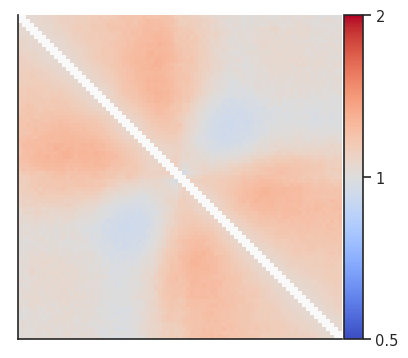

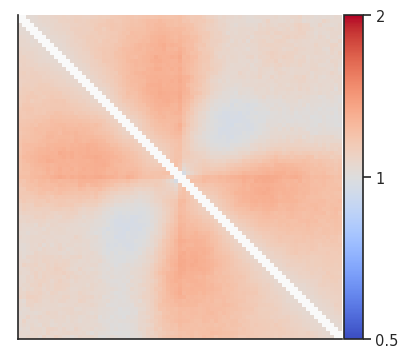

In [6]:
## NOT matchmakers only 
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/'
subdir = 'erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed'
track = pd.read_csv(os.path.join(datapath, subdir), sep='\t')

track_sub = track[(track['quant']==0) | (track['quant']==1)]
track_sub['chrom'] = track_sub['chr']
track_sub['start'] = track_sub['coord']-100
track_sub['end'] = track_sub['coord']+100
    
for p in [0, 1, 2]:
    clr = phase_clrs[p]
    exp0 =  pd.read_csv(exps[p], sep='\t')
    
    pup = coolpup.pileup(clr, track_sub, features_format='bed', local=True, view_df=hg38_arms,
                                        flank=200_000, expected_df = exp0, min_diag=0, nproc=8)
    fg = plotpup.plot(pup,
                             score=False, cmap='coolwarm', scale='log', sym=True,
                             height=5, vmax=2)

    fg
    #fg.savefig(os.path.join(savedir, f"notmatchmaker_joined_p{p+1}.svg"))
    
    
    

In [2]:
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/'
subdir = 'erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed'
track = pd.read_csv(os.path.join(datapath, subdir), sep='\t')

global_max = 2.25

for quant in range(4):
    track_sub = track[track['quant']==quant]
    track_sub['chrom'] = track_sub['chr']
    track_sub['start'] = track_sub['coord']-100
    track_sub['end'] = track_sub['coord']+100
    
    for p in [0, 1, 2]:
        clr = phase_clrs[p]
        exp0 =  pd.read_csv(exps[p], sep='\t')
    
        pup = coolpup.pileup(clr, track_sub, features_format='bed', local=True, view_df=hg38_arms,
                                        flank=200_000, expected_df = exp0, min_diag=0, nproc=8)
        fg = plotpup.plot(pup,
                             score=False, cmap='coolwarm', scale='log', sym=True,
                             height=5, vmax=global_max)

        fg.savefig(os.path.join(savedir, f"phase{p+1}_quant{quant}_sameScale.svg"))

NameError: name 'pd' is not defined

INFO:coolpuppy:('chr8_p', 'chr8_p'): 6
INFO:coolpuppy:('chr5_p', 'chr5_p'): 4
INFO:coolpuppy:('chr4_p', 'chr4_p'): 2
INFO:coolpuppy:('chr7_p', 'chr7_p'): 5
INFO:coolpuppy:('chr6_p', 'chr6_p'): 8
INFO:coolpuppy:('chr8_q', 'chr8_q'): 7
INFO:coolpuppy:('chr3_p', 'chr3_p'): 14
INFO:coolpuppy:('chr2_p', 'chr2_p'): 13
INFO:coolpuppy:('chr9_p', 'chr9_p'): 2
INFO:coolpuppy:('chr7_q', 'chr7_q'): 8
INFO:coolpuppy:('chr1_p', 'chr1_p'): 17
INFO:coolpuppy:('chr6_q', 'chr6_q'): 8
INFO:coolpuppy:('chr10_p', 'chr10_p'): 4
INFO:coolpuppy:('chr4_q', 'chr4_q'): 12
INFO:coolpuppy:('chr5_q', 'chr5_q'): 21
INFO:coolpuppy:('chr9_q', 'chr9_q'): 15
INFO:coolpuppy:('chr11_p', 'chr11_p'): 10
INFO:coolpuppy:('chr12_p', 'chr12_p'): 4
INFO:coolpuppy:('chr3_q', 'chr3_q'): 12
INFO:coolpuppy:('chr10_q', 'chr10_q'): 14
INFO:coolpuppy:('chr13_q', 'chr13_q'): 3
INFO:coolpuppy:('chr14_q', 'chr14_q'): 12
INFO:coolpuppy:('chr11_q', 'chr11_q'): 12
INFO:coolpuppy:('chr17_p', 'chr17_p'): 3
INFO:coolpuppy:('chr16_p', 'chr16_p')

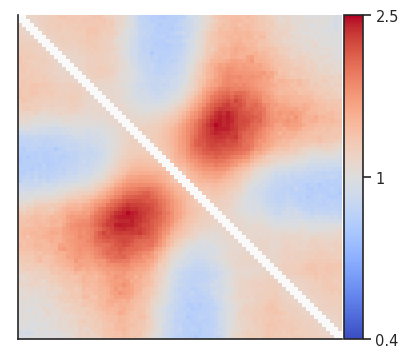

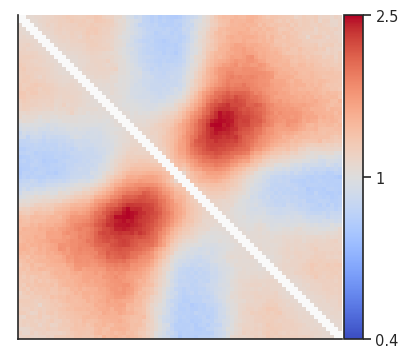

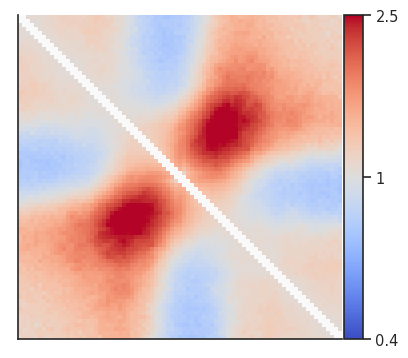

In [5]:
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/'
subdir = 'erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed'
track = pd.read_csv(os.path.join(datapath, subdir), sep='\t')

for quant in [3]:
    track_sub = track[track['quant']==quant]
    track_sub['chrom'] = track_sub['chr']
    track_sub['start'] = track_sub['coord']-100
    track_sub['end'] = track_sub['coord']+100
    
    for p in [0, 1, 2]:
        clr = phase_clrs[p]
        exp0 =  pd.read_csv(exps[p], sep='\t')
    
        pup = coolpup.pileup(clr, track_sub, features_format='bed', local=True, view_df=hg38_arms,
                                        flank=200_000, expected_df = exp0, min_diag=0, nproc=8)
        fg = plotpup.plot(pup,
                             score=False, cmap='coolwarm', scale='log', sym=True,
                             height=5, vmax=2.5)

        fg
        #fg.savefig(os.path.join(savedir, f"phase{p+1}_quant{quant}_sameScale.svg"))